## Text Preprocessing & Lexical Exploration

Sentiment-aware tokenisation, negation preservation, stop-word removal, word clouds, top bigrams per sentiment class, and preprocessing export for downstream modeling.

Loaded dataset: ../data/final_pseudo_labeled_dataset.csv (22,448 rows)
Columns: ['review_id', 'review', 'rating', 'sentiment', 'label_source', 'prediction_confidence', 'needs_human_review', 'split_role', 'is_autotag', 'store_name', 'store_address', 'review_time', 'days_ago', 'review_clean', 'rating_num', 'reviewer_id']

Free-text reviews used for NLP: 22448

Sentiment distribution (Imbalanced Target):
sentiment
Negative    10626
Positive     8292
Neutral      3530
Name: count, dtype: int64

Sentiment percentages:
sentiment
Negative    47.34
Positive    36.94
Neutral     15.73
Name: proportion, dtype: float64

Reviews remaining after preprocessing: 22366


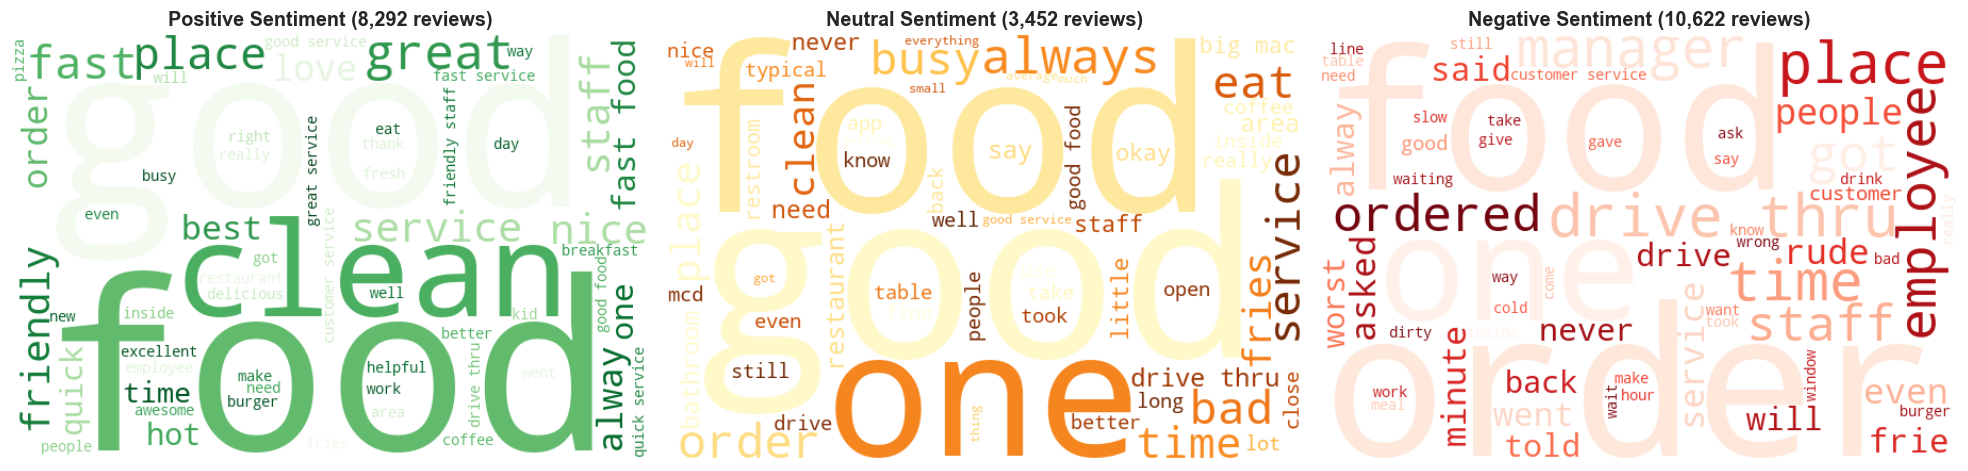

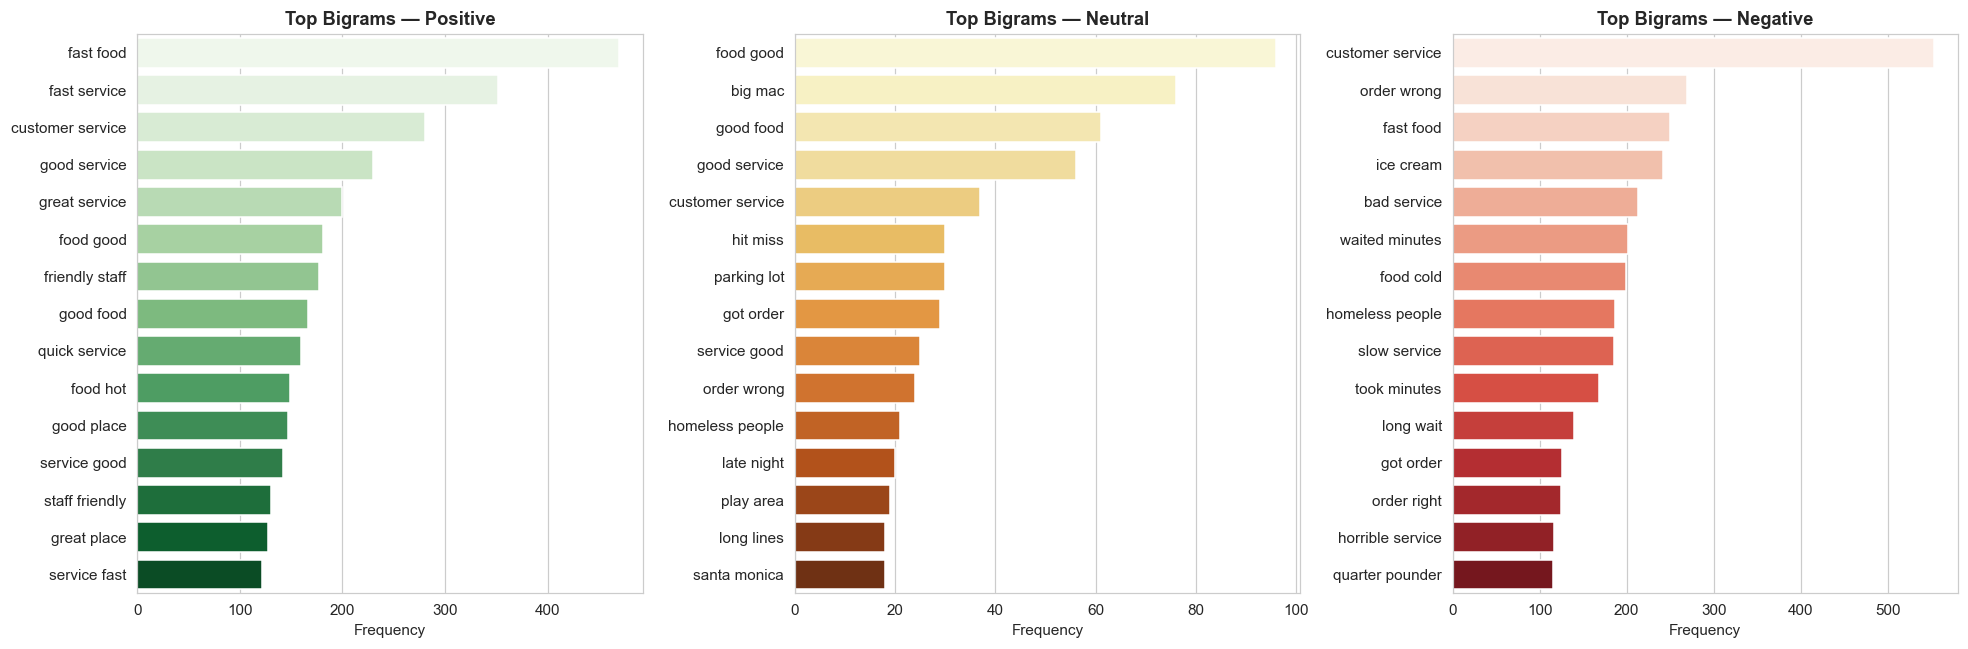


Successfully exported processed reviews -> text_reviews_processed.csv (22,366 rows)


In [1]:
%matplotlib inline
import os
import re
import warnings
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.feature_extraction.text import CountVectorizer

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

# Output paths
OUTPUT_FILE = "text_reviews_processed.csv"
FIG = "../Figures" if os.path.exists("../Figures") else "Figures"
os.makedirs(FIG, exist_ok=True)

# ============================================================
# 1. Load Dataset
# ============================================================
DATA_PATH = "../data/final_pseudo_labeled_dataset.csv"
if not os.path.exists(DATA_PATH):
    DATA_PATH = "../data/cleaned_reviews.csv"

df = pd.read_csv(DATA_PATH)

# Standardize column aliases across schemas
if "review" in df.columns and "review_clean" not in df.columns:
    df["review_clean"] = df["review"]
if "rating" in df.columns and "rating_num" not in df.columns:
    df["rating_num"] = df["rating"]
if "review_id" in df.columns and "reviewer_id" not in df.columns:
    df["reviewer_id"] = df["review_id"]
if "is_autotag" not in df.columns:
    df["is_autotag"] = False

print(f"Loaded dataset: {DATA_PATH} ({len(df):,} rows)")
print("Columns:", df.columns.tolist())

# ============================================================
# 2. Filter Genuine Free-Text Reviews
# ============================================================
# Only genuine free-text reviews are used for NLP/text modelling
text_df = df[~df["is_autotag"]].copy()
print("\nFree-text reviews used for NLP:", len(text_df))

print("\nSentiment distribution (Imbalanced Target):")
print(text_df["sentiment"].value_counts())
print("\nSentiment percentages:")
print(text_df["sentiment"].value_counts(normalize=True).mul(100).round(2))

# ============================================================
# 3. Sentiment-Aware Text Preprocessing
# ============================================================
DOMAIN_STOPWORDS = {
    "mcdonalds", "mcdonald", "mc", "donalds", "location", "store"
}

# Critical: preserve negation words that invert sentiment
NEGATION_WORDS = {
    "not", "no", "never", "neither", "nor", "cannot", "without"
}

CONTRACTIONS = {
    "can't": "can not", "cannot": "can not", "won't": "will not",
    "wouldn't": "would not", "shouldn't": "should not", "couldn't": "could not",
    "didn't": "did not", "doesn't": "does not", "don't": "do not",
    "isn't": "is not", "wasn't": "was not", "weren't": "were not",
    "aren't": "are not", "haven't": "have not", "hasn't": "has not",
    "hadn't": "had not", "i'm": "i am", "it's": "it is",
    "that's": "that is", "there's": "there is"
}

def preprocess(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    for contraction, replacement in CONTRACTIONS.items():
        text = text.replace(contraction, replacement)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = []
    for word in text.split():
        if word in NEGATION_WORDS:
            tokens.append(word)
        elif word in DOMAIN_STOPWORDS:
            continue
        elif len(word) <= 2:
            continue
        else:
            tokens.append(word)
    return " ".join(tokens)

# Apply preprocessing
text_df["review_processed"] = text_df["review_clean"].fillna("").apply(preprocess)
text_df = text_df[text_df["review_processed"].str.strip().str.len() > 0].copy()

print("\nReviews remaining after preprocessing:", len(text_df))

# ============================================================
# 4. Word Clouds by Sentiment
# ============================================================
classes = ["Positive", "Neutral", "Negative"]
colors_map = {"Positive": "Greens", "Neutral": "YlOrBr", "Negative": "Reds"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, sentiment in zip(axes, classes):
    subset = text_df[text_df["sentiment"] == sentiment]
    corpus = " ".join(subset["review_processed"].dropna().tolist())
    if corpus.strip():
        wc = WordCloud(width=600, height=400, background_color="white",
                       colormap=colors_map[sentiment], max_words=60, random_state=42).generate(corpus)
        ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"{sentiment} Sentiment ({len(subset):,} reviews)", fontsize=13, fontweight="bold")
    ax.axis("off")

plt.tight_layout()
plt.savefig(f"{FIG}/05_wordclouds.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# 5. Top N-Gram Bigrams per Sentiment
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, sentiment in zip(axes, classes):
    subset = text_df[text_df["sentiment"] == sentiment]
    cv = CountVectorizer(ngram_range=(2, 2), stop_words="english", max_features=15)
    bow = cv.fit_transform(subset["review_processed"].dropna())
    counts = np.asarray(bow.sum(axis=0)).ravel()
    features = cv.get_feature_names_out()
    top_idx = np.argsort(counts)[::-1]
    top_feats = [features[i] for i in top_idx]
    top_counts = [counts[i] for i in top_idx]

    sns.barplot(x=top_counts, y=top_feats, ax=ax, palette=colors_map[sentiment])
    ax.set_title(f"Top Bigrams — {sentiment}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Frequency")

plt.tight_layout()
plt.savefig(f"{FIG}/06_top_bigrams.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# 6. Export Processed Dataset
# ============================================================
text_df.to_csv(OUTPUT_FILE, index=False, encoding="utf-8")
print(f"\nSuccessfully exported processed reviews -> {OUTPUT_FILE} ({len(text_df):,} rows)")
